# 1. import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import (RandomForestClassifier, BaggingClassifier,
                               AdaBoostClassifier, GradientBoostingClassifier)
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# StandardScaler : Feature scaling — transforms features to zero mean, unit variance
# train_test_split : Splits dataset into training and testing subsets
# accuracy_score, classification_report, confusion_matrix : Model evaluation metrics
# RandomForestClassifier  : Ensemble of Decision Trees using bagging
# BaggingClassifier       : Generic bagging wrapper for any base estimator
# AdaBoostClassifier      : Adaptive Boosting — sequential model correction
# GradientBoostingClassifier : Gradient Boosting — builds trees on residual errors

# Task 1 — Exploratory Data Analysis (EDA)

### DATA LOADING

In [2]:
df = pd.read_excel("glass.xlsx", sheet_name="glass")

In [3]:
df.shape

(214, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [5]:
df.isna().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [6]:
df.duplicated().sum()

1

In [7]:
df.drop_duplicates(inplace=True, ignore_index=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (213, 10)


In [8]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000
mean,1.518348,13.404085,2.679202,1.449484,72.655070,0.498873,8.954085,0.175869,0.057277,2.788732
std,0.003033,0.816662,1.443691,0.495925,0.773998,0.653185,1.425882,0.498245,0.097589,2.105130
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516520,12.900000,2.090000,1.190000,72.280000,0.130000,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.560000,8.600000,0.000000,0.000000,2.000000
75%,1.519150,13.810000,3.600000,1.630000,73.090000,0.610000,9.150000,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [9]:
print("Target class distribution:")
print(df['Type'].value_counts())
# Target class distribution — shows how many samples belong to each glass Type.

Target class distribution:
Type
2    76
1    69
7    29
3    17
5    13
6     9
Name: count, dtype: int64


# Task 2 — Data Visualisation

### VISUALISATION 1 — Histogram + KDE for every numerical feature

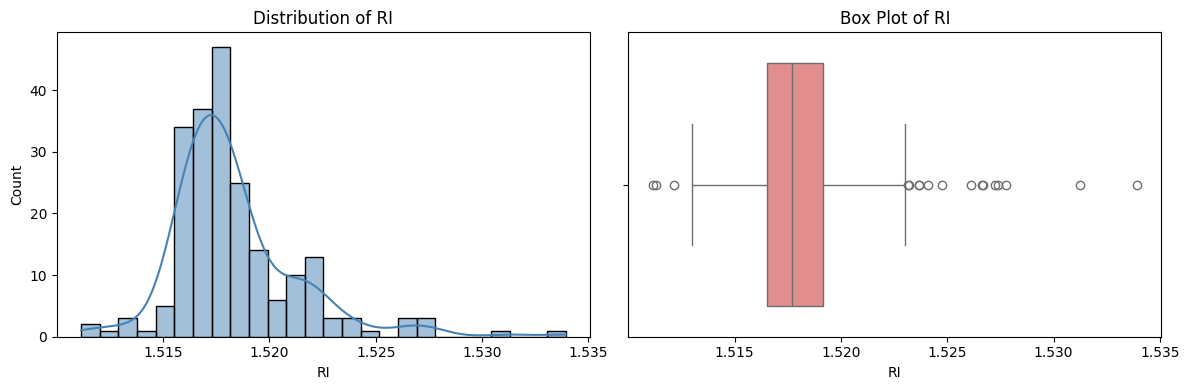

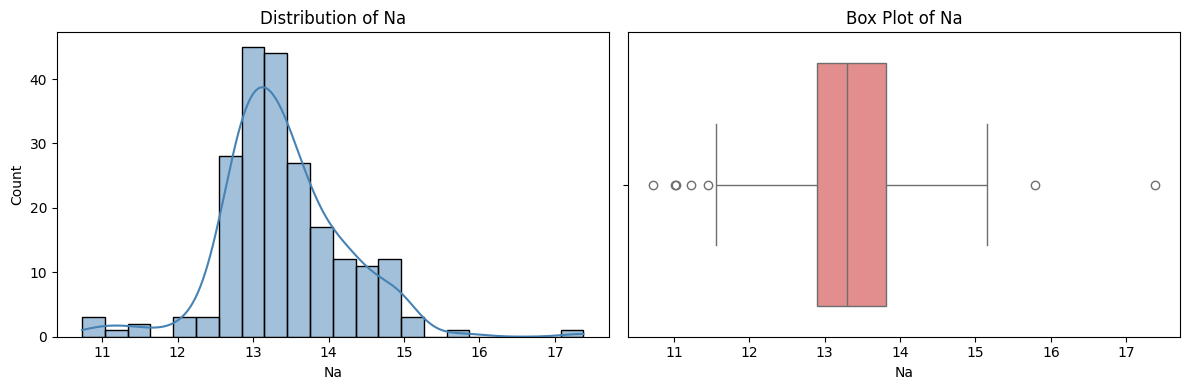

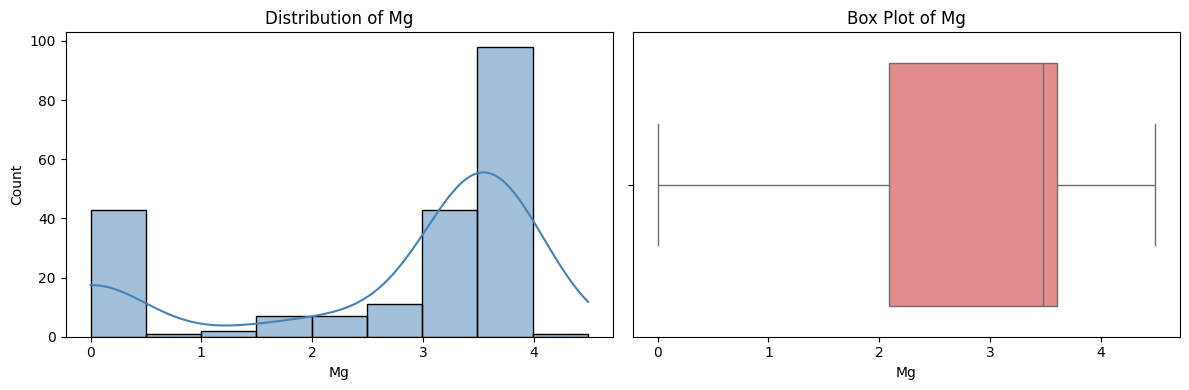

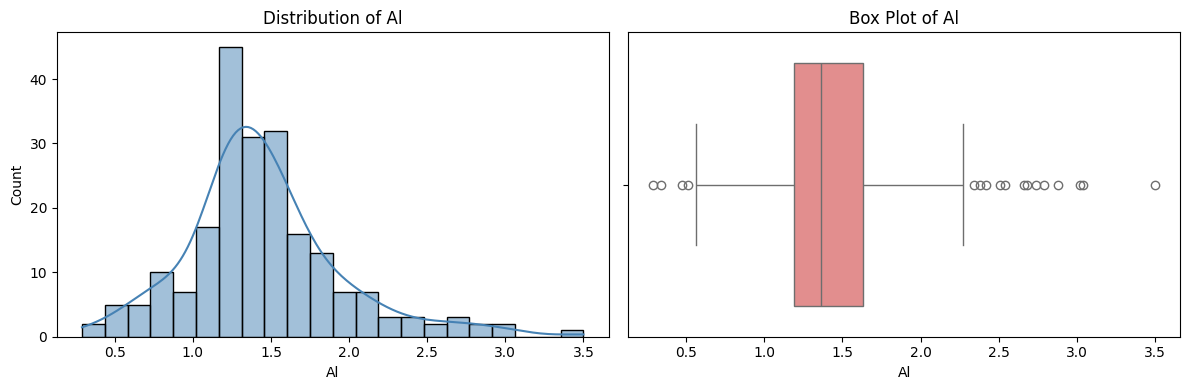

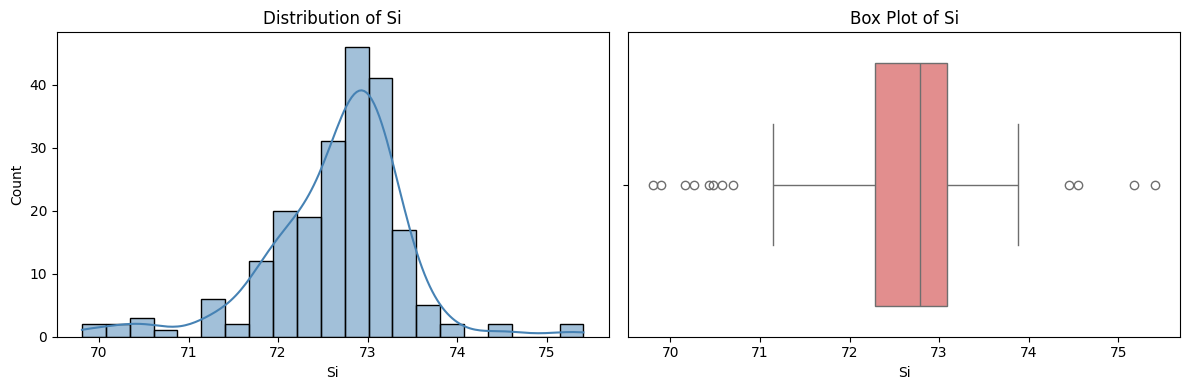

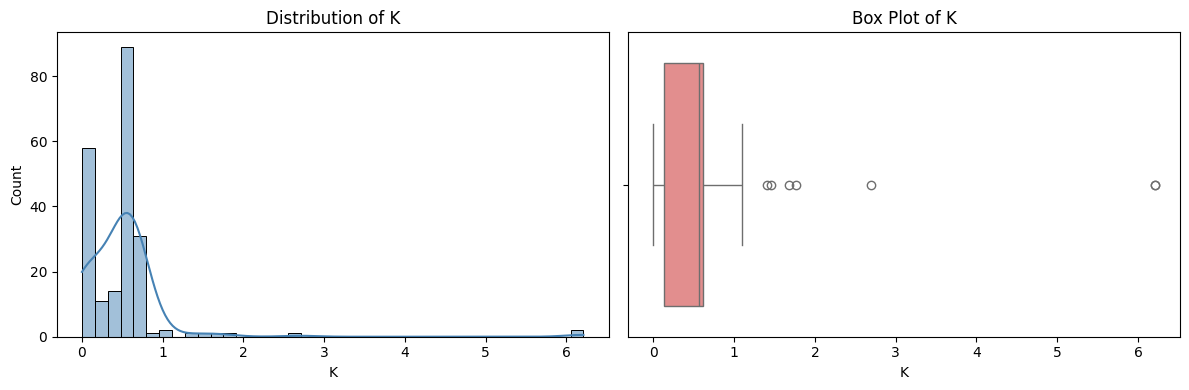

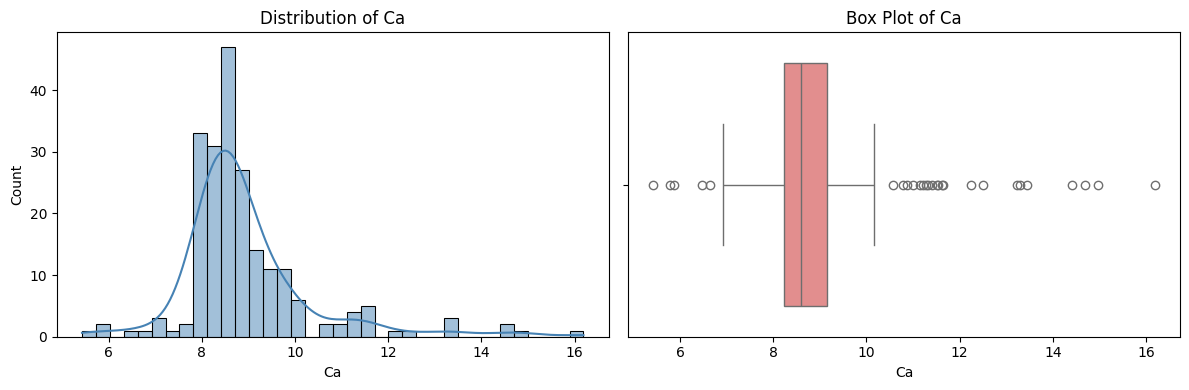

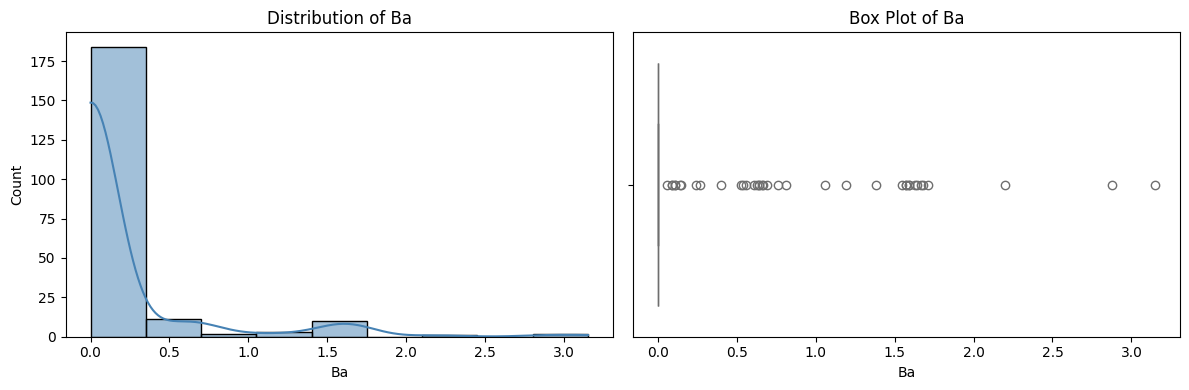

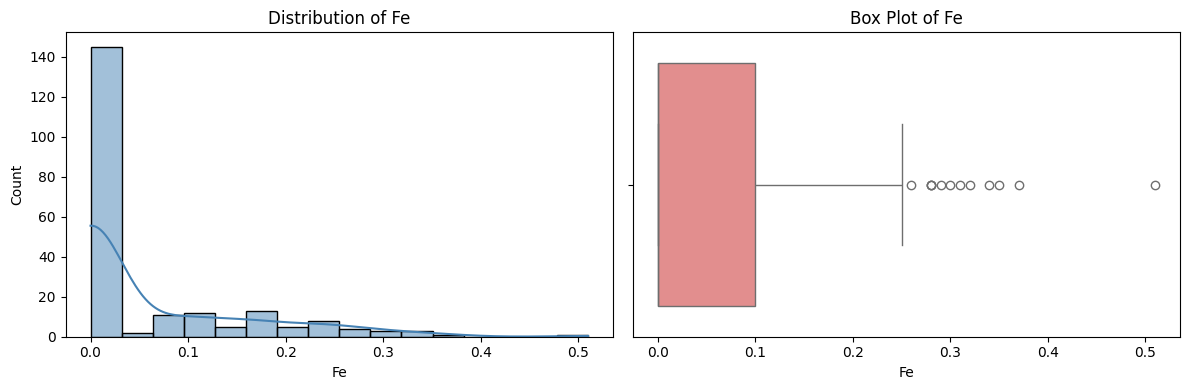

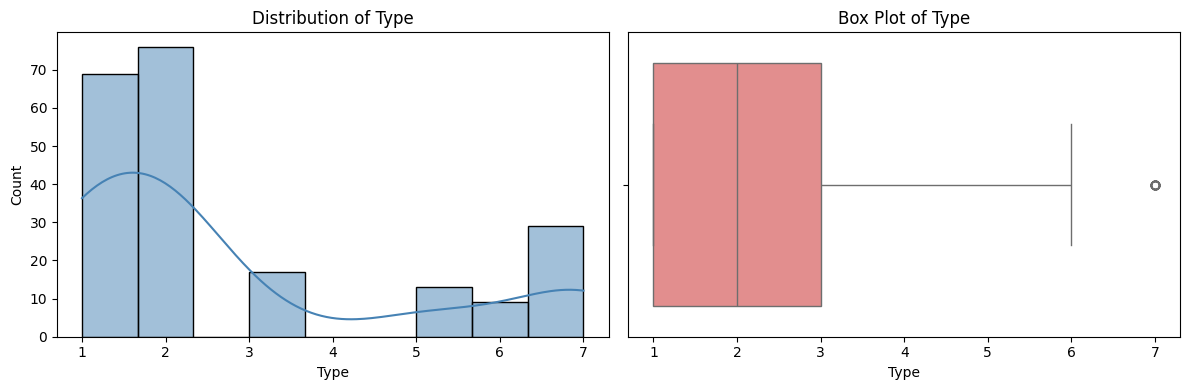

In [10]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram with KDE
    sns.histplot(df[col], kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel(col)

    # Box plot
    # DEFINITION: A box plot shows the median (line inside box), IQR (box height),
    #             and whiskers (1.5 × IQR). Points beyond whiskers are outliers.
    # WHY: Provides a compact, visual summary of spread and outliers per feature.
    sns.boxplot(x=df[col], ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Box Plot of {col}')

    plt.tight_layout()
    plt.show()

# VISUALISATION 2 — Correlation Heatmap

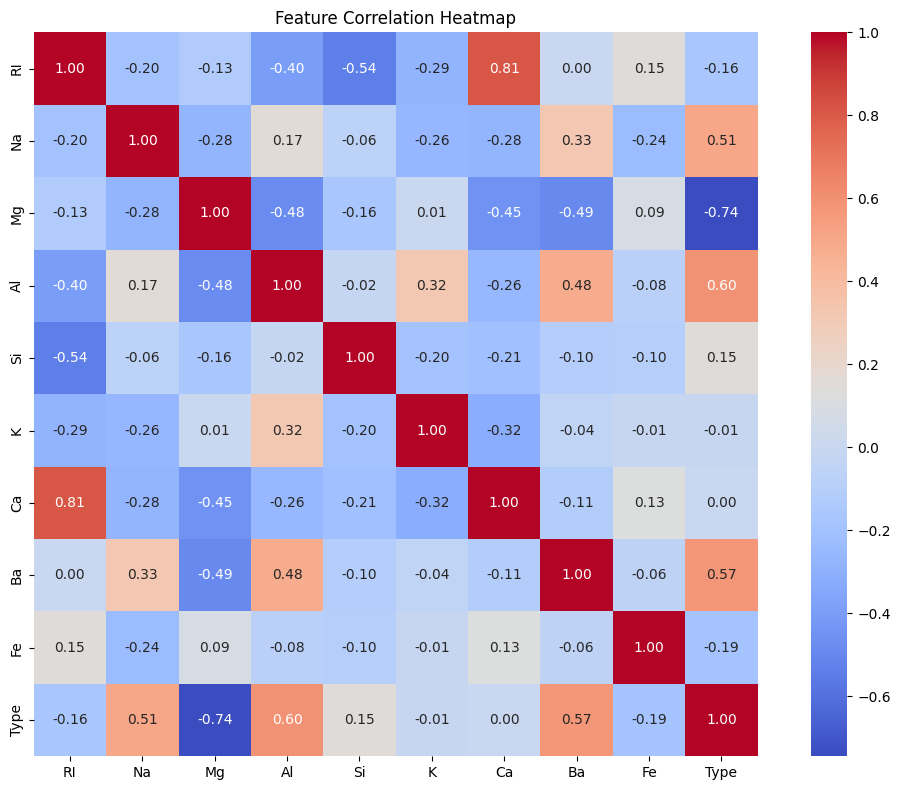

In [11]:
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# VISUALISATION 3 — Pair Plot

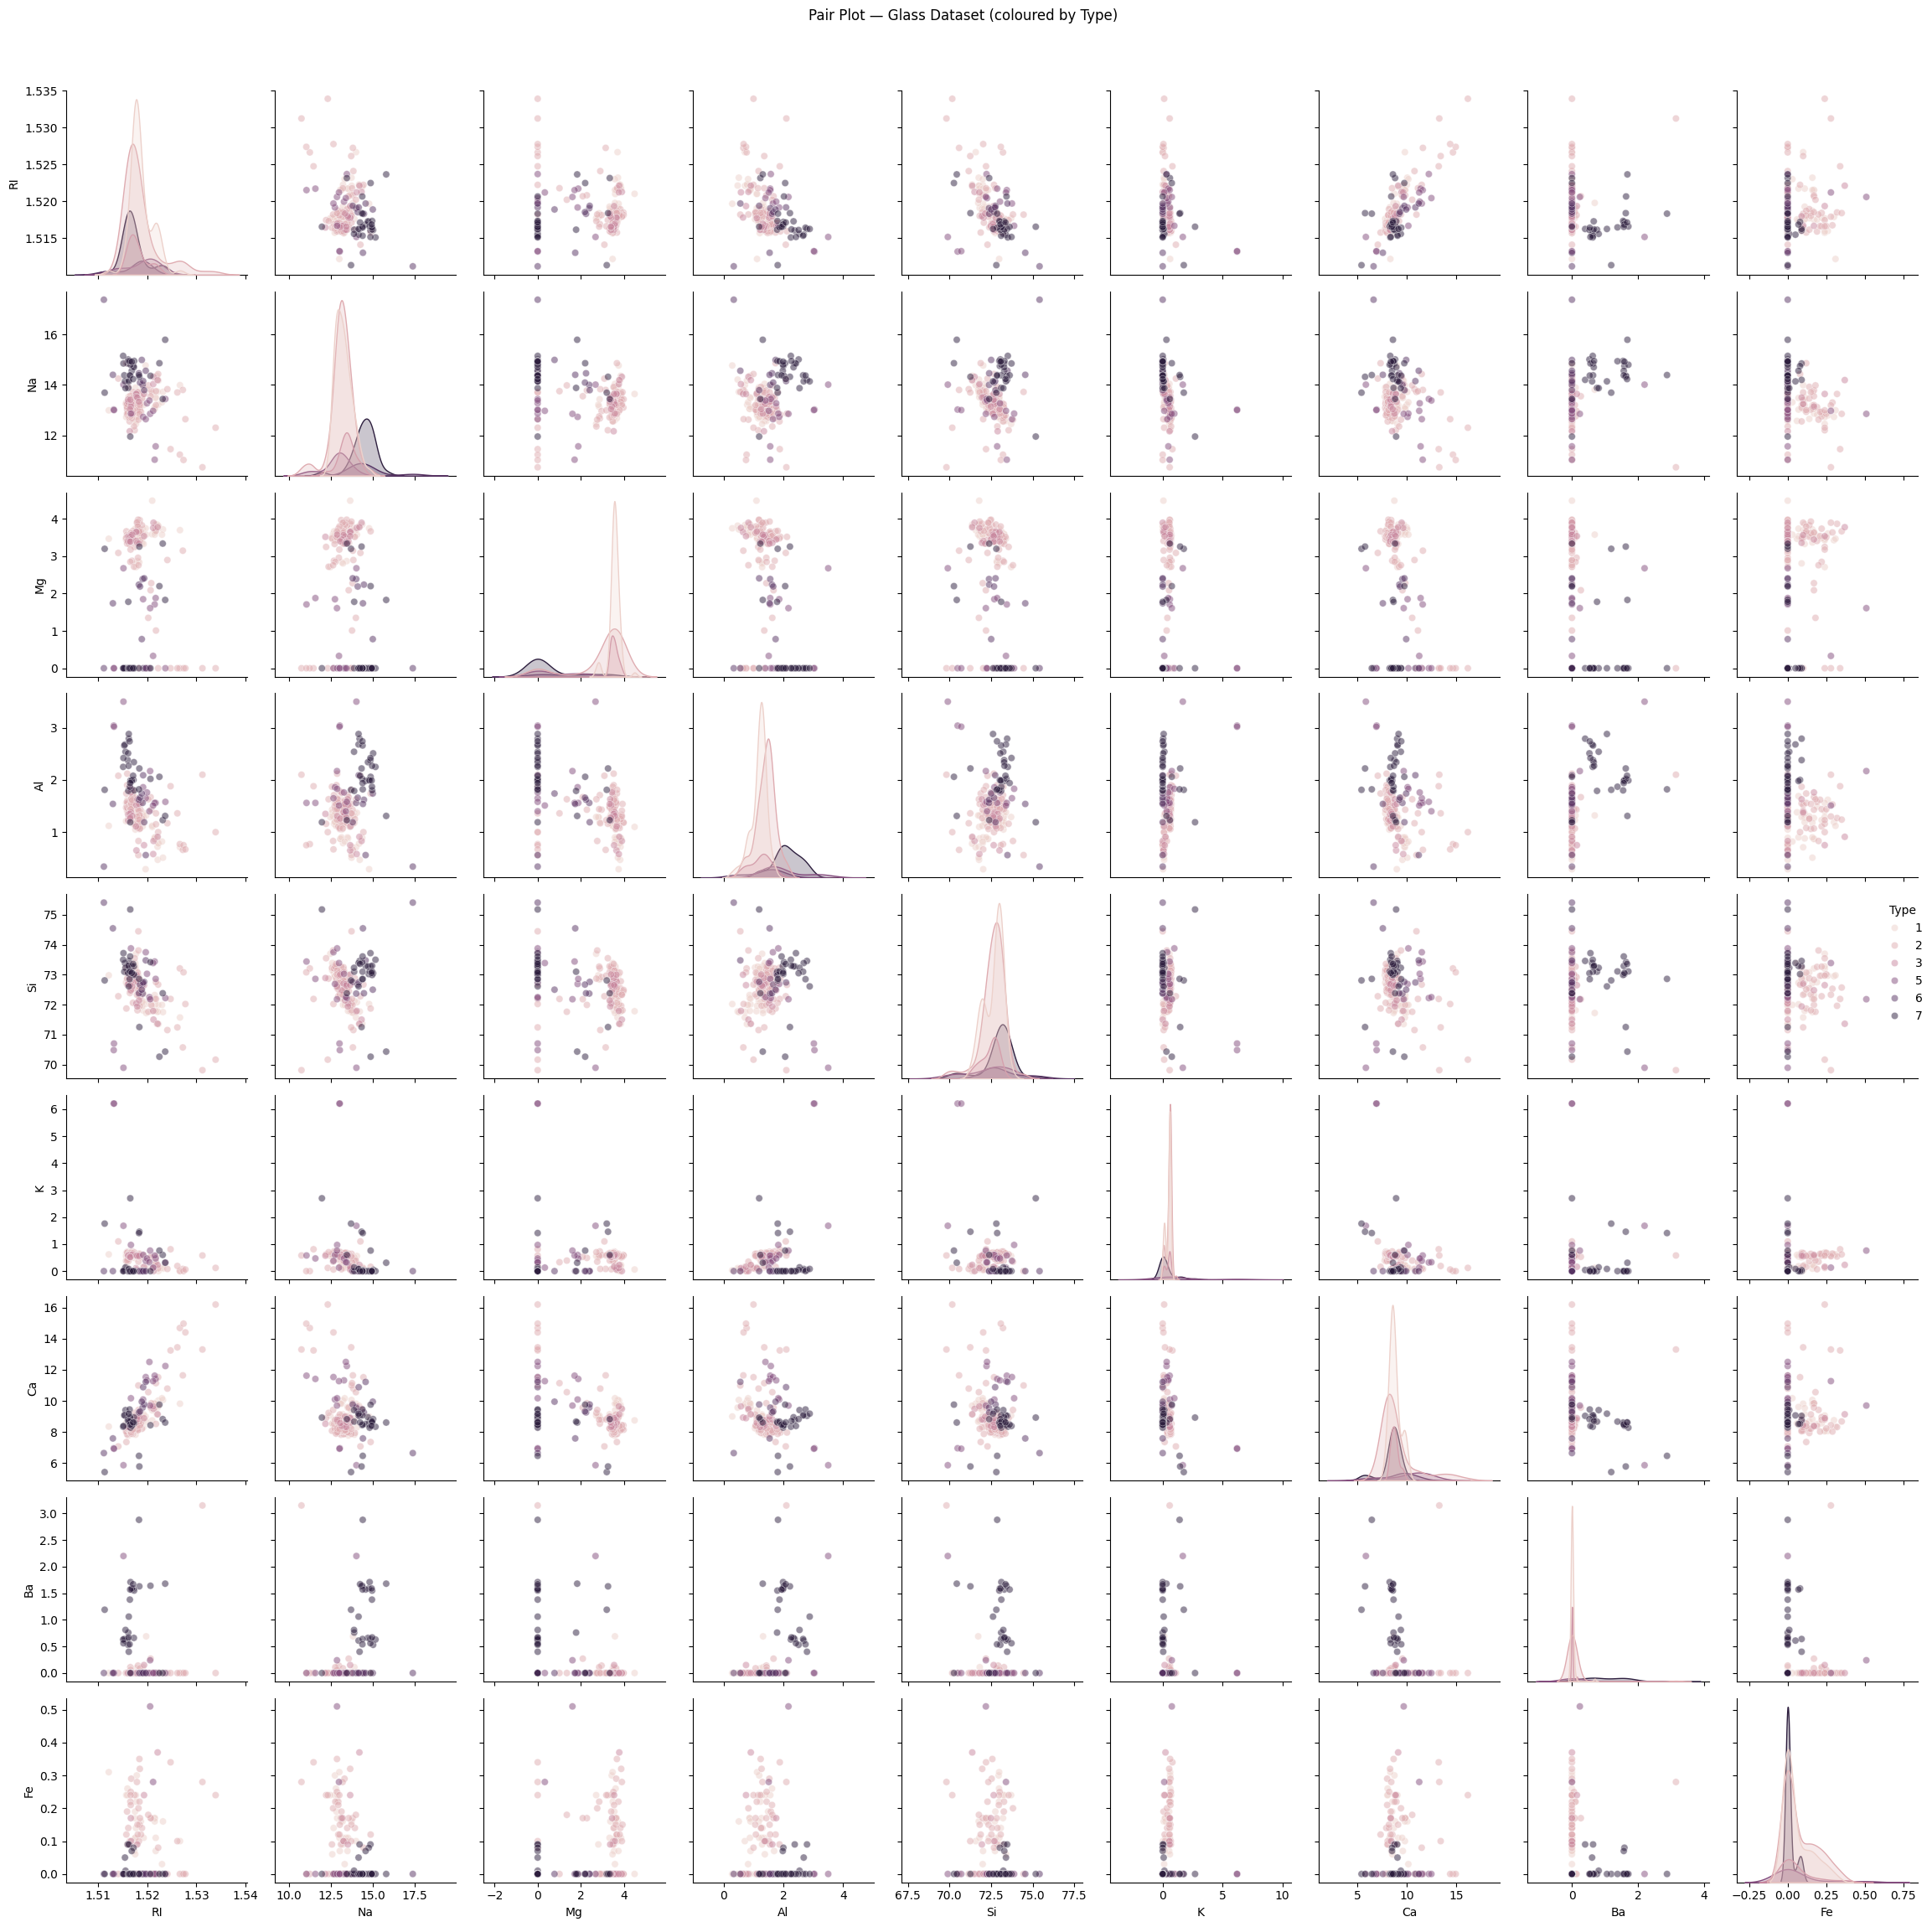

In [12]:
sns.pairplot(df, hue='Type', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle("Pair Plot — Glass Dataset (coloured by Type)", y=1.02)
plt.tight_layout()
plt.show()

# VISUALISATION 4 — Box Plot BEFORE Outlier Capping

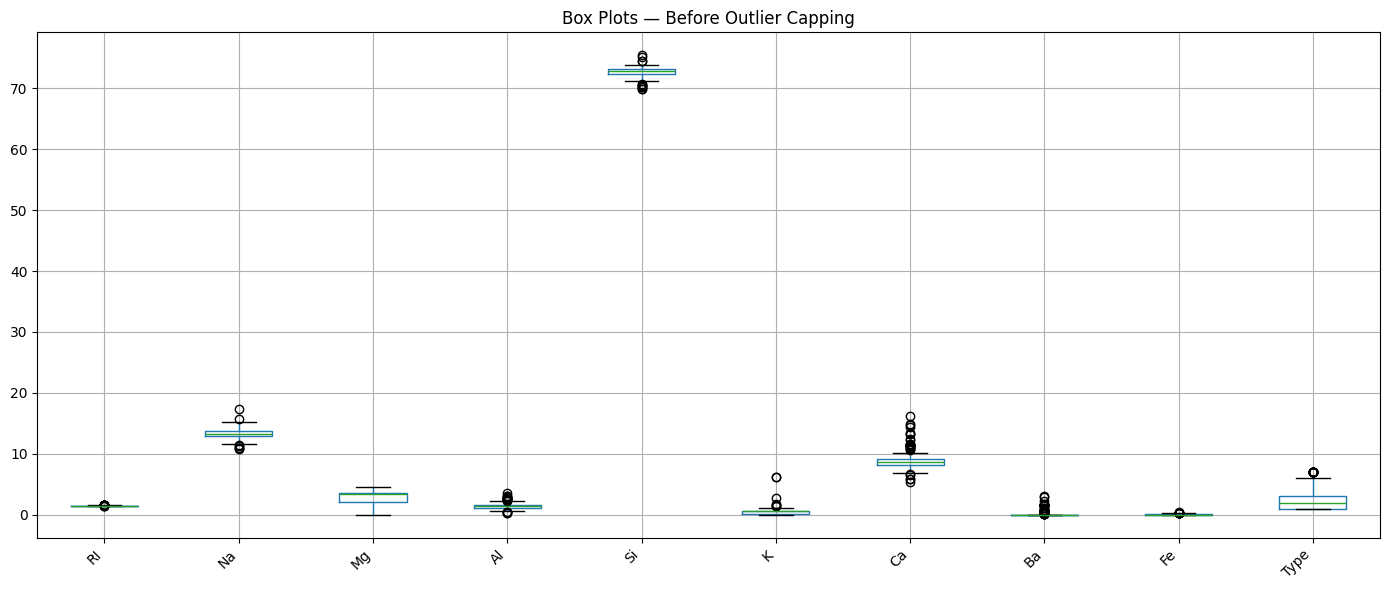

In [13]:
plt.figure(figsize=(14, 6))
df.select_dtypes(include=['float64', 'int64']).boxplot()
plt.title("Box Plots — Before Outlier Capping")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# OUTLIER CAPPING (IQR Method)

In [14]:
def outlier_capping(df, column):
    """
    Caps outliers in a single numerical column using the IQR fence method.
    Modifies the DataFrame column in-place.
    """
    Q1  = df[column].quantile(0.25)
    Q3  = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR    # minimum acceptable boundary
    upper_fence = Q3 + 1.5 * IQR    # maximum acceptable boundary
    df[column] = df[column].apply(
        lambda x: lower_fence if x < lower_fence
                  else upper_fence if x > upper_fence
                  else x
    )

# Apply to every numerical column (both int and float types)
for col in df.select_dtypes(['int', 'float']).columns:
    outlier_capping(df, col)

print("Outlier capping complete.")

Outlier capping complete.


# VISUALISATION 5 — Box Plot AFTER Outlier Capping

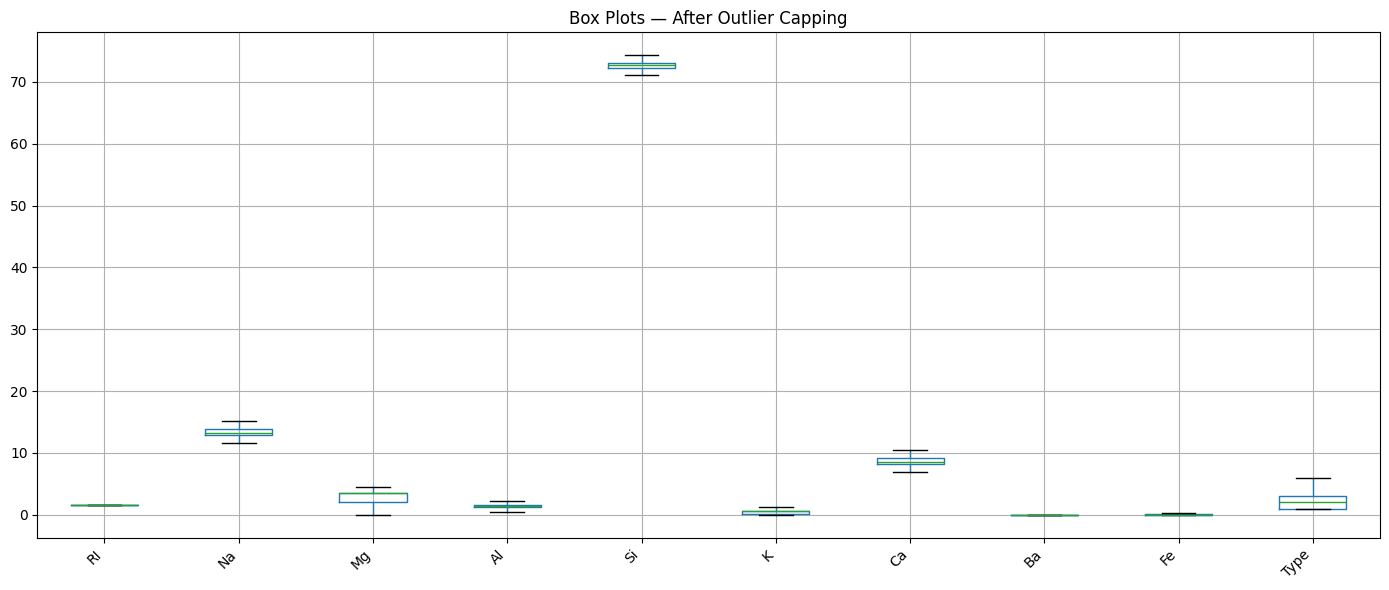

In [15]:
plt.figure(figsize=(14, 6))
df.select_dtypes(include=['float64', 'int64']).boxplot()
plt.title("Box Plots — After Outlier Capping")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Task 3 — Data Preprocessing

In [16]:
# STEP 1 — Handle Missing Values
df = df.fillna(df.median(numeric_only=True))
print("Missing values after imputation:", df.isna().sum().sum())

Missing values after imputation: 0


In [17]:
# Separate input features (X) from the output label (y).
features = df.drop(columns=['Type'])   # X : 9 chemical/optical properties
target   = df['Type']                  # y : glass type (1-7, multi-class)

print('Features shape:', features.shape)
print('Target distribution:')
print(target.value_counts())

Features shape: (213, 9)
Target distribution:
Type
2.0    76
1.0    69
6.0    38
3.0    17
5.0    13
Name: count, dtype: int64


In [18]:
# STEP 2 — Handle Class Imbalance (Manual Oversampling)
print("Class counts BEFORE oversampling:")
print(target.value_counts())

df_balanced = pd.concat([features, target], axis=1)
majority_count = target.value_counts().max()

# Oversample each class that has fewer samples than the majority class
oversampled_dfs = []
for glass_type in target.unique():
    class_subset = df_balanced[df_balanced['Type'] == glass_type]
    if len(class_subset) < majority_count:
        # resample with replacement to reach majority_count samples
        class_upsampled = resample(class_subset,
                                   replace=True,
                                   n_samples=majority_count,
                                   random_state=42)
        oversampled_dfs.append(class_upsampled)
    else:
        oversampled_dfs.append(class_subset)

df_resampled = pd.concat(oversampled_dfs).sample(frac=1, random_state=42).reset_index(drop=True)

x_res = df_resampled.drop(columns=['Type'])
y_res = df_resampled['Type']

print("\nClass counts AFTER oversampling:")
print(y_res.value_counts())

Class counts BEFORE oversampling:
Type
2.0    76
1.0    69
6.0    38
3.0    17
5.0    13
Name: count, dtype: int64

Class counts AFTER oversampling:
Type
5.0    76
1.0    76
6.0    76
3.0    76
2.0    76
Name: count, dtype: int64


In [19]:
# STEP 3 — Feature Scaling (StandardScaler)
scaler   = StandardScaler()
x_scaled = scaler.fit_transform(x_res)

print("Scaling complete. Feature means (should be ~0):", x_scaled.mean(axis=0).round(2))

Scaling complete. Feature means (should be ~0): [-0.  0.  0.  0.  0. -0. -0.  0.  0.]


# Task 4 — Random Forest Model Implementation

In [20]:
# TRAIN / TEST SPLIT
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y_res, test_size=0.2, random_state=42, stratify=y_res
)
print(f"Training samples : {len(x_train)}")
print(f"Testing  samples : {len(x_test)}")

Training samples : 304
Testing  samples : 76


In [21]:
# RANDOM FOREST — Train
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(x_train, y_train)
print("Random Forest trained successfully.")

Random Forest trained successfully.


In [22]:
rf_pred = rf.predict(x_test)

Random Forest Performance:
Accuracy : 0.9079

Classification Report:
               precision    recall  f1-score   support

         1.0       0.88      0.93      0.90        15
         2.0       0.91      0.67      0.77        15
         3.0       0.93      0.93      0.93        15
         5.0       0.84      1.00      0.91        16
         6.0       1.00      1.00      1.00        15

    accuracy                           0.91        76
   macro avg       0.91      0.91      0.90        76
weighted avg       0.91      0.91      0.90        76



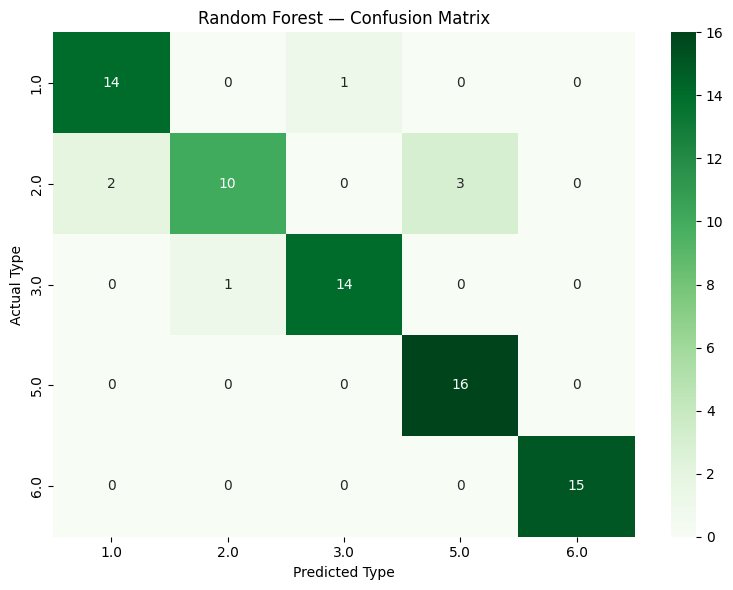

In [23]:
# EVALUATION — Random Forest
print("Random Forest Performance:")
print(f"Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d',
            cmap='Greens', xticklabels=sorted(y_res.unique()),
            yticklabels=sorted(y_res.unique()))
plt.title("Random Forest — Confusion Matrix")
plt.ylabel("Actual Type")
plt.xlabel("Predicted Type")
plt.tight_layout()
plt.show()


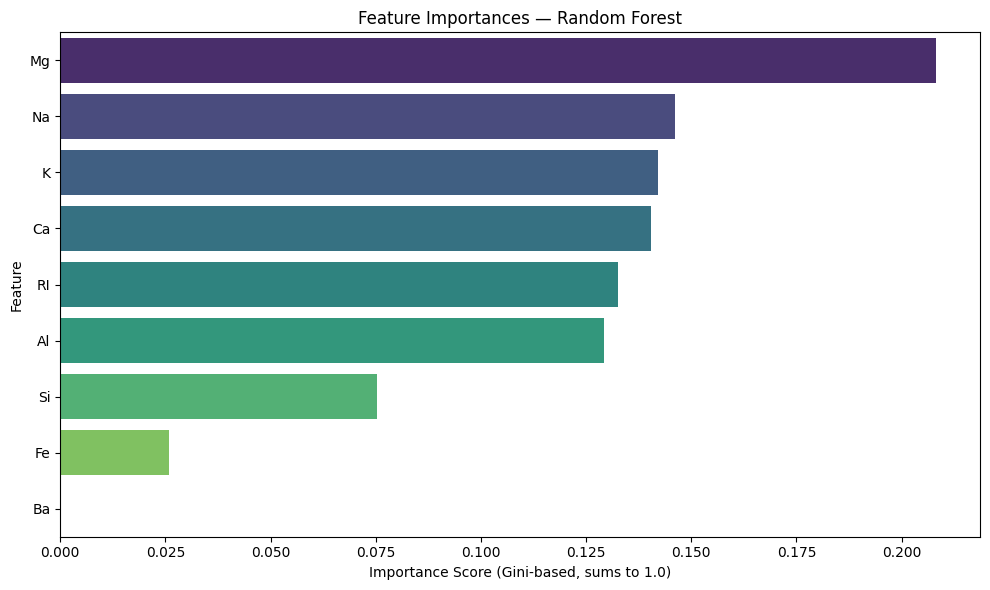

Feature  Importance
     Mg    0.208231
     Na    0.146211
      K    0.142001
     Ca    0.140484
     RI    0.132654
     Al    0.129261
     Si    0.075236
     Fe    0.025922
     Ba    0.000000


In [24]:
# FEATURE IMPORTANCE — Random Forest
importance_df = pd.DataFrame({
    'Feature'   : x_res.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Feature Importances — Random Forest")
plt.xlabel("Importance Score (Gini-based, sums to 1.0)")
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))


# Task 5 — Bagging and Boosting Methods

Bagging Classifier Performance:
Accuracy : 0.8947

Classification Report:
               precision    recall  f1-score   support

         1.0       0.82      0.93      0.88        15
         2.0       0.90      0.60      0.72        15
         3.0       0.93      0.93      0.93        15
         5.0       0.84      1.00      0.91        16
         6.0       1.00      1.00      1.00        15

    accuracy                           0.89        76
   macro avg       0.90      0.89      0.89        76
weighted avg       0.90      0.89      0.89        76



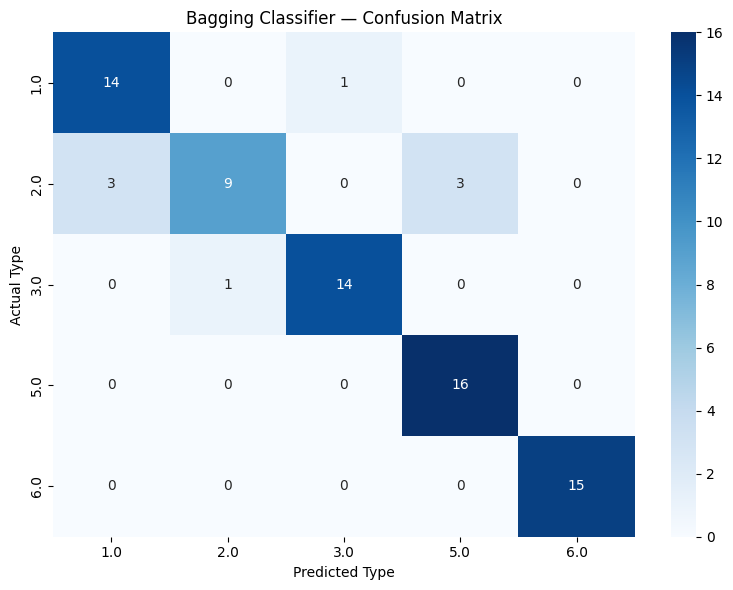

In [25]:
bag = BaggingClassifier(
    estimator=RandomForestClassifier(),
    n_estimators=50,
    random_state=42
)
bag.fit(x_train, y_train)
bag_pred = bag.predict(x_test)

print("Bagging Classifier Performance:")
print(f"Accuracy : {accuracy_score(y_test, bag_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, bag_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, bag_pred), annot=True, fmt='d',
            cmap='Blues', xticklabels=sorted(y_res.unique()),
            yticklabels=sorted(y_res.unique()))
plt.title("Bagging Classifier — Confusion Matrix")
plt.ylabel("Actual Type")
plt.xlabel("Predicted Type")
plt.tight_layout()
plt.show()


AdaBoost Performance:
Accuracy : 0.5263

Classification Report:
               precision    recall  f1-score   support

         1.0       0.59      0.67      0.62        15
         2.0       0.35      0.47      0.40        15
         3.0       0.62      0.53      0.57        15
         5.0       0.00      0.00      0.00        16
         6.0       0.60      1.00      0.75        15

    accuracy                           0.53        76
   macro avg       0.43      0.53      0.47        76
weighted avg       0.43      0.53      0.46        76



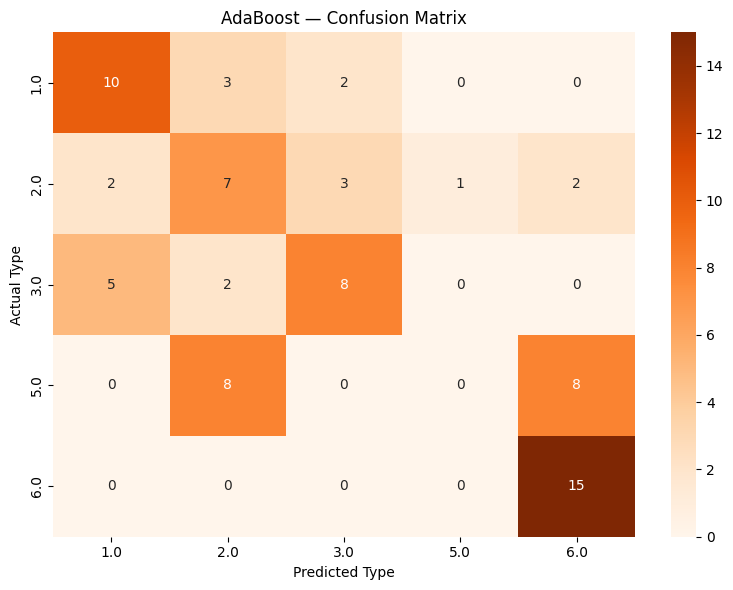

In [26]:
# ADABOOST (Adaptive Boosting)
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(x_train, y_train)
ada_pred = ada.predict(x_test)

print("AdaBoost Performance:")
print(f"Accuracy : {accuracy_score(y_test, ada_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, ada_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, ada_pred), annot=True, fmt='d',
            cmap='Oranges', xticklabels=sorted(y_res.unique()),
            yticklabels=sorted(y_res.unique()))
plt.title("AdaBoost — Confusion Matrix")
plt.ylabel("Actual Type")
plt.xlabel("Predicted Type")
plt.tight_layout()
plt.show()


Gradient Boosting Performance:
Accuracy : 0.9211

Classification Report:
               precision    recall  f1-score   support

         1.0       0.87      0.87      0.87        15
         2.0       0.92      0.73      0.81        15
         3.0       0.94      1.00      0.97        15
         5.0       0.89      1.00      0.94        16
         6.0       1.00      1.00      1.00        15

    accuracy                           0.92        76
   macro avg       0.92      0.92      0.92        76
weighted avg       0.92      0.92      0.92        76



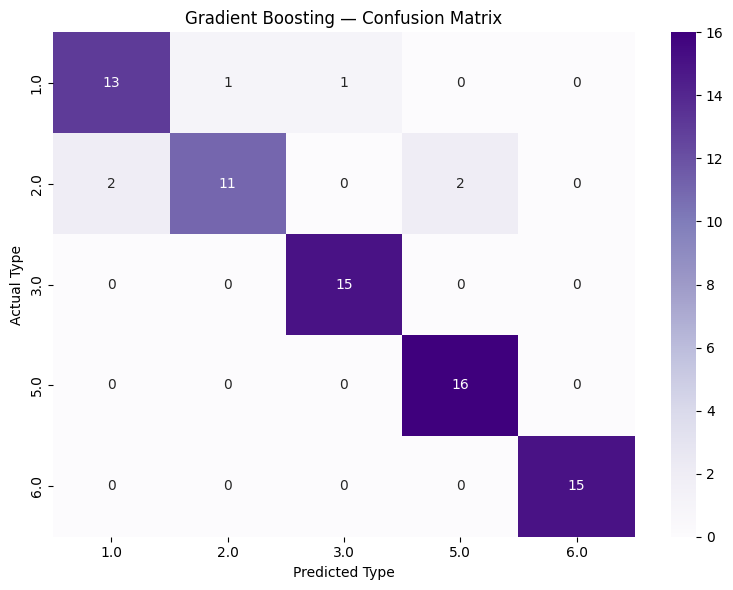

In [27]:
# GRADIENT BOOSTING CLASSIFIER
gb = GradientBoostingClassifier(random_state=42)
gb.fit(x_train, y_train)
gb_pred = gb.predict(x_test)

print("Gradient Boosting Performance:")
print(f"Accuracy : {accuracy_score(y_test, gb_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, gb_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, gb_pred), annot=True, fmt='d',
            cmap='Purples', xticklabels=sorted(y_res.unique()),
            yticklabels=sorted(y_res.unique()))
plt.title("Gradient Boosting — Confusion Matrix")
plt.ylabel("Actual Type")
plt.xlabel("Predicted Type")
plt.tight_layout()
plt.show()


            Model  Accuracy
Gradient Boosting  0.921053
    Random Forest  0.907895
          Bagging  0.894737
         AdaBoost  0.526316


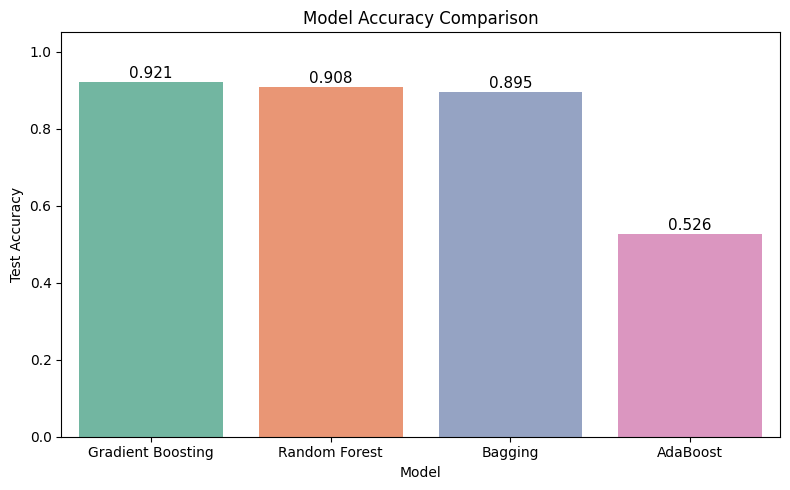

In [28]:
# MODEL COMPARISON SUMMARY
results = pd.DataFrame({
    'Model'   : ['Random Forest', 'Bagging', 'AdaBoost', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, bag_pred),
        accuracy_score(y_test, ada_pred),
        accuracy_score(y_test, gb_pred)
    ]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results, palette='Set2')
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1.05)
plt.ylabel("Test Accuracy")
for i, row in results.iterrows():
    plt.text(i, row['Accuracy'] + 0.01, f"{row['Accuracy']:.3f}", ha='center', fontsize=11)
plt.tight_layout()
plt.show()


## Additional Notes

### 1. Bagging and Boosting — How are they different?

Bagging means building many models at the same time, each on a different random sample of the data. All models work independently and do not know about each other. At the end, they all vote and the majority decision is the final answer. The main goal is to reduce overfitting. Random Forest is a good example of bagging.

Boosting means building models one by one in a sequence. Each new model looks at where the previous model went wrong and tries to fix those mistakes. So every model learns from the errors of the one before it. The main goal is to keep improving accuracy step by step. AdaBoost and Gradient Boosting are examples of this.

The simple difference is that bagging builds models in parallel and averages them to reduce overfitting, while boosting builds models in sequence where each one corrects the last, to improve accuracy.

### 2. How to handle imbalance in the data

Imbalanced data means some classes have a lot of samples and some have very few. This is a problem because the model will mostly learn the majority class and ignore the smaller ones.

There are three simple ways to fix this.

The first is oversampling, where you increase the number of samples in the minority class. You can do this by duplicating existing samples or using SMOTE which creates new synthetic samples by mixing existing minority class points.

The second is undersampling, where you reduce the number of samples in the majority class by randomly removing some rows. This works when the dataset is large enough that losing data is not a problem.

The third is using class weights. You set class_weight='balanced' in the model and it automatically gives more importance to the minority class during training without changing the data at all.